## Trabajo Práctico N°2: Predicción de lluvia en Australia.


## Aprendizaje Automático I

Mayo 2026

Estudiantes:

Diez Laureano

Duvia Uriel

Quispe Rocio



## Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de clasificación y la evaluación de métricas, con TensorFlow para el entrenamiento de redes neuronales y con Docker para la puesta en producción del modelo seleccionado como el más adecuado, entre otras.

## Dataset

El dataset se llama weatherAUS_2026C1.csv y contiene información climática de Australia de los últimos diez años, incluyendo si para el día siguiente llovió o no en la columna ‘RainTomorrow’. El objetivo del trabajo práctico es armar un ejecutable de Docker para predecir, a las 23:59hs de cada día, si el día siguiente va a llover o no.

Tiene una columna ‘Location’ que indica la ciudad donde se obtuvo la observación. 


##  Descripción de las variables


| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Date` | Temporal | Fecha de la observación |
| `Location` | Categórica nominal | Ciudad donde se registraron los datos |
| `MinTemp` | Continua | Temperatura mínima del día (°C) |
| `MaxTemp` | Continua | Temperatura máxima del día (°C) |
| `Rainfall` | Continua | Cantidad de lluvia registrada durante el día (mm) |
| `Evaporation` | Continua | Cantidad de evaporación (mm) |
| `Sunshine` | Continua | Cantidad de horas de sol |
| `WindGustDir` | Categórica nominal | Dirección de la ráfaga máxima de viento |
| `WindGustSpeed` | Continua | Velocidad máxima del viento (km/h) |
| `WindDir9am` | Categórica nominal | Dirección del viento a las 9 AM |
| `WindDir3pm` | Categórica nominal | Dirección del viento a las 3 PM |
| `WindSpeed9am` | Continua | Velocidad del viento a las 9 AM (km/h) |
| `WindSpeed3pm` | Continua | Velocidad del viento a las 3 PM (km/h) |
| `Humidity9am` | Continua | Humedad relativa a las 9 AM (%) |
| `Humidity3pm` | Continua | Humedad relativa a las 3 PM (%) |
| `Pressure9am` | Continua | Presión atmosférica a las 9 AM (hPa) |
| `Pressure3pm` | Continua | Presión atmosférica a las 3 PM (hPa) |
| `Cloud9am` | Continua | Cobertura de nubes a las 9 AM (0 = despejado, 8 = cubierto) |
| `Cloud3pm` | Continua | Cobertura de nubes a las 3 PM (0 = despejado, 8 = cubierto) |
| `Temp9am` | Continua | Temperatura a las 9 AM (°C) |
| `Temp3pm` | Continua | Temperatura a las 3 PM (°C) |
| `RainToday` | Categórica binaria | Indica si llovió en el día actual (Yes/No) |
| `RainTomorrow` | Categórica binaria | Indica si lloverá al día siguiente (Yes/No) (**variable objetivo**) |
| `RainfallTomorrow` | Continua | Cantidad de lluvia del día siguiente (mm) |

# 1. Configuración del entorno y carga de datos  

Configuración del entorno



In [2]:
# Se importan las librerías necesarias
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer

In [3]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

Carga de datos

In [4]:
df = pd.read_csv('weatherAUS_2026C1.csv')

# 2. Inspección estructural del dataset  

In [5]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()

Dimensiones del dataset: 145412 filas x 25 columnas
Memoria utilizada: 74.53 MB



### Visualización general del dataset

In [6]:
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Se observa una columna que es irrelevante para el trabajo.

### Visualización de los datos

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

Se observan muchas variables con datos nulos.

### Limpieza inicial de datos


La variable RainfallTomorrow contiene información del futuro (cantidad de lluvia del día siguiente). Dado que el objetivo es predecir RainTomorrow (llueve o no mañana) esta variable no estaría disponible en un escenario real de predicción, por lo que incluirla generaría un problema de data leakage.

In [8]:
# Eliminamos las columnas Unnamed y RainfallTomorrow
df = df.drop(columns=["Unnamed: 0", "RainfallTomorrow"], errors="ignore")


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145412 non-null  str    
 1   Location       145412 non-null  str    
 2   MinTemp        143928 non-null  float64
 3   MaxTemp        144159 non-null  float64
 4   Rainfall       142152 non-null  float64
 5   Evaporation    82658 non-null   float64
 6   Sunshine       75616 non-null   float64
 7   WindGustDir    135096 non-null  str    
 8   WindGustSpeed  135159 non-null  float64
 9   WindDir9am     134850 non-null  str    
 10  WindDir3pm     141186 non-null  str    
 11  WindSpeed9am   143645 non-null  float64
 12  WindSpeed3pm   142351 non-null  float64
 13  Humidity9am    142759 non-null  float64
 14  Humidity3pm    140907 non-null  float64
 15  Pressure9am    130351 non-null  float64
 16  Pressure3pm    130388 non-null  float64
 17  Cloud9am       89542 non-null   float64


In [10]:
# Convertimos la fecha en formato datetime
df["Date"] = pd.to_datetime(df["Date"])

### Separación de variables

Se separarán las variables del dataset en variables numéricas y categóricas según su tipo de dato.


In [11]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()


print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Variables categoricas (6): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


### Estadisticas descriptivas

In [12]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 115)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
MinTemp,12.196528,12.0,6.417956,52.621169,-9.7,7.6,12.0,16.9,34.1,0.019449,-0.478637
MaxTemp,23.223064,22.6,7.135927,30.727759,-5.1,17.9,22.6,28.2,49.1,0.218606,-0.221082
Rainfall,2.361516,0.0,8.479338,359.063354,0.0,0.0,0.0,0.8,371.0,9.834819,178.099955
Evaporation,5.468616,4.8,4.193871,76.689792,0.0,2.6,4.8,7.4,145.0,3.761159,45.041191
Sunshine,7.611241,8.4,3.785612,49.737121,0.0,4.8,8.4,10.6,14.5,-0.496503,-0.829508
WindGustSpeed,40.036668,38.0,13.648259,34.089399,6.0,31.0,38.0,48.0,135.0,0.867216,1.402022
WindSpeed9am,14.067277,13.0,8.936768,63.528769,0.0,7.0,13.0,19.0,130.0,0.787317,1.219027
WindSpeed3pm,18.661899,18.0,8.865457,47.505651,0.0,12.0,18.0,24.0,86.0,0.616980,0.730063
Humidity9am,68.861521,69.9,19.062866,27.682901,0.0,57.0,69.9,83.1,100.0,-0.486012,-0.042284
Humidity3pm,51.532206,52.0,20.844414,40.449296,0.0,36.6,52.0,65.7,100.0,0.031449,-0.509916


In [13]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 105)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
   MinTemp: sesgo=+0.019 [aproximadamente simetrica], curtosis=-0.479 [mesocurtica]
   MaxTemp: sesgo=+0.219 [aproximadamente simetrica], curtosis=-0.221 [mesocurtica]
  Rainfall: sesgo=+9.835 [sesgo positivo (alto)], curtosis=+178.100 [leptocurtica (colas pesadas)]
  Evaporation: sesgo=+3.761 [sesgo positivo (alto)], curtosis=+45.041 [leptocurtica (colas pesadas)]
  Sunshine: sesgo=-0.497 [aproximadamente simetrica], curtosis=-0.830 [platicurtica (colas livianas)]
  WindGustSpeed: sesgo=+0.867 [sesgo positivo (moderado)], curtosis=+1.402 [leptocurtica (colas pesadas)]
  WindSpeed9am: sesgo=+0.787 [sesgo positivo (moderado)], curtosis=+1.219 [leptocurtica (colas pesadas)]
  WindSpeed3pm: sesgo=+0.617 [sesgo positivo (moderado)], curtosis=+0.730 [leptocurtica (colas pesadas)]
  Humidity9am: sesgo=-0.486 [aproximadamente simetrica], curtosis=-0.042 [mesocurtica]
  Humidity3pm: sesgo=+0.031 [aproximadamente simetrica], curtosis=-0.510 [platicurtica (co

Las variables: MinTemp, MaxTemp, Pressure9am/3pm, Humidity9am/3pm, Temp9am/3pm al ser mesocúrticas se comportan casi como una campana de Gauss. Presentan una distribución equilibrada y esto facilita el aprendizaje del modelo ya que no presentan valores extremos que distorsionen la media de forma significativa.

Las variables: Rainfall y Evaporation al ser leptocúrticas tienen valores de curtosis de +178 y sesgo de +9.8. Esto es extremo e indica que la gran mayoría de los días tienen 0 o muy poca lluvia, pero hay unos pocos días con tormentas masivas (outliers). La "cola" de la distribución es larguísima hacia la derecha.

Las variables: Sunshine, Cloud9am, Cloud3pm tiene una curtosis negativa (platicúrtica) significa que los datos están muy dispersos y la distribución es "achatada". No tienen picos claros ni outliers extremos. Y es lógico porque suelen medirse en una escala fija (oktas) del 0 al 8, por lo que los datos se reparten más uniformemente en ese rango.

### Distribuciones de Variables numéricas

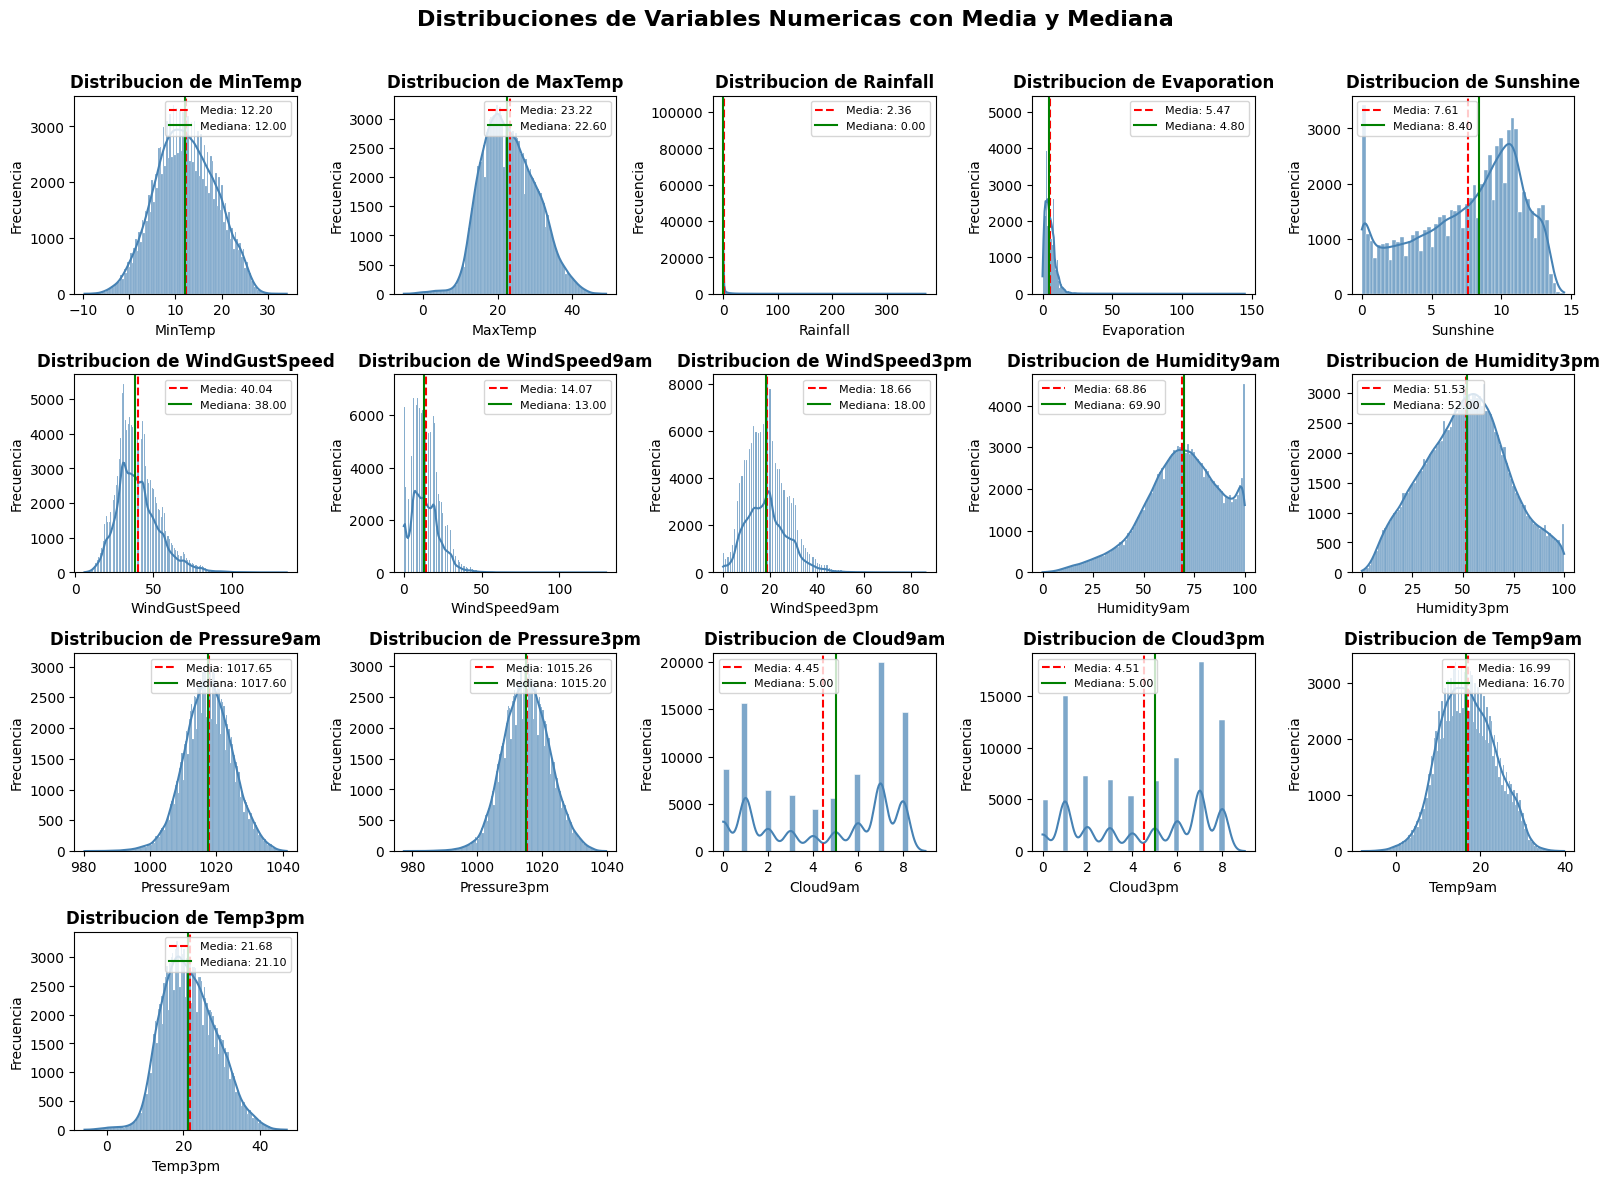

In [14]:
fig, axes = plt.subplots(5, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Interpretación

Temperaturas

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") presentan medias y medianas muy similares, lo que indica

distribuciones aproximadamente simétricas. El sesgo cercano a cero confirma esta simetría, mientras que la curtosis ligeramente 
 
 negativa indica distribuciones sin colas extremas.

Además, el coeficiente de variación es moderado (30%–50%), lo que refleja una variabilidad esperable en este tipo de mediciones.

Se trata de variables estables y bien comportadas.


Rainfall

La variable "Rainfall" presenta una gran diferencia entre la media (2.36) y la mediana (0), lo que indica una fuerte asimetría.

El coeficiente de variación es extremadamente alto (359%), y el sesgo (9.83) junto con la curtosis (178) confirman una distribución

altamente sesgada con valores extremos.

Esto refleja que la mayoría de los días no llueve, pero cuando ocurre esto, puede haber precipitaciones muy intensas.

Se trata de una variable con alta variabilidad y presencia de outliers.


Evaporation y Sunshine

Las variables "Evaporation" y "Sunshine" presentan cierta asimetría, especialmente "Evaporation", donde la media es mayor que la 

mediana y el sesgo es elevado.

El coeficiente de variación en ambas variables es relativamente alto, indicando una variabilidad considerable.

Tambien, "Evaporation" muestra una curtosis alta, lo que sugiere la presencia de valores extremos.


Viento

Las variables de viento ("WindGustSpeed", "WindSpeed9am", "WindSpeed3pm") presentan un sesgo positivo moderado, lo que indica que 

existen algunos valores altos poco frecuentes.

Las medias son ligeramente superiores a las medianas, lo cual refuerza esta asimetría.

El coeficiente de variación es moderado a alto, reflejando variabilidad en la intensidad del viento.

Esto es consistente con la presencia ocasional de ráfagas fuertes.


Humedad

Las variables de humedad ("Humidity9am", "Humidity3pm") presentan medias y medianas muy cercanas, lo que indica distribuciones 

simétricas.

El sesgo es cercano a cero y la curtosis indica ausencia de colas extremas.

El coeficiente de variación es moderado, lo que sugiere una variabilidad normal en las condiciones de humedad.


Presión

Las variables de presión ("Pressure9am", "Pressure3pm") presentan medias y medianas prácticamente iguales, indicando distribuciones

altamente simétricas.

El coeficiente de variación es muy bajo (<1%), lo que muestra una gran estabilidad en estas mediciones.

El sesgo y la curtosis cercanos a cero refuerzan que son variables bien distribuidas y sin valores extremos.


Nubosidad

Las variables "Cloud9am" y "Cloud3pm" presentan medias cercanas a la mediana, aunque con leve asimetría negativa.

El coeficiente de variación es alto, lo que indica dispersión en los niveles de nubosidad.

La curtosis negativa sugiere distribuciones más planas, sin concentración fuerte en valores centrales.

Cabe destacar que estas variables son discretas (valores entre 0 y 9).



En general, se observa que variables como temperatura y presión presentan comportamientos estables y simétricos, mientras que 

variables como "Rainfall" y "Evaporation" muestran alta variabilidad y asimetría, lo cual es consistente con fenómenos climáticos

reales.

Estas diferencias serán relevantes al momento de aplicar técnicas de preprocesamiento y modelado.

### Distribución de Variables Categóricas

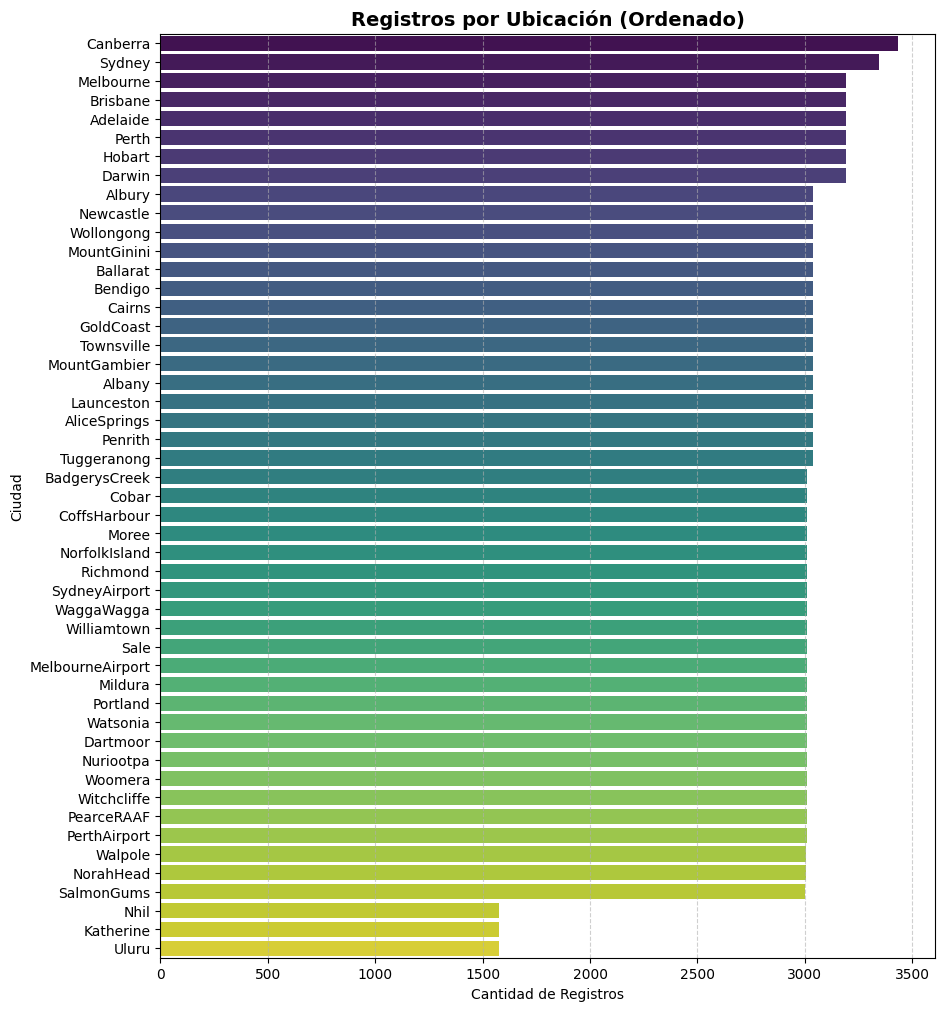

In [15]:
plt.figure(figsize=(10, 12))

# Location en eje Y
sns.countplot(y='Location', data=df, palette='viridis', 
              order=df['Location'].value_counts().index) 

plt.title('Registros por Ubicación (Ordenado)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Registros')
plt.ylabel('Ciudad')
plt.grid(axis='x', linestyle='--', alpha=0.6) 
plt.show()

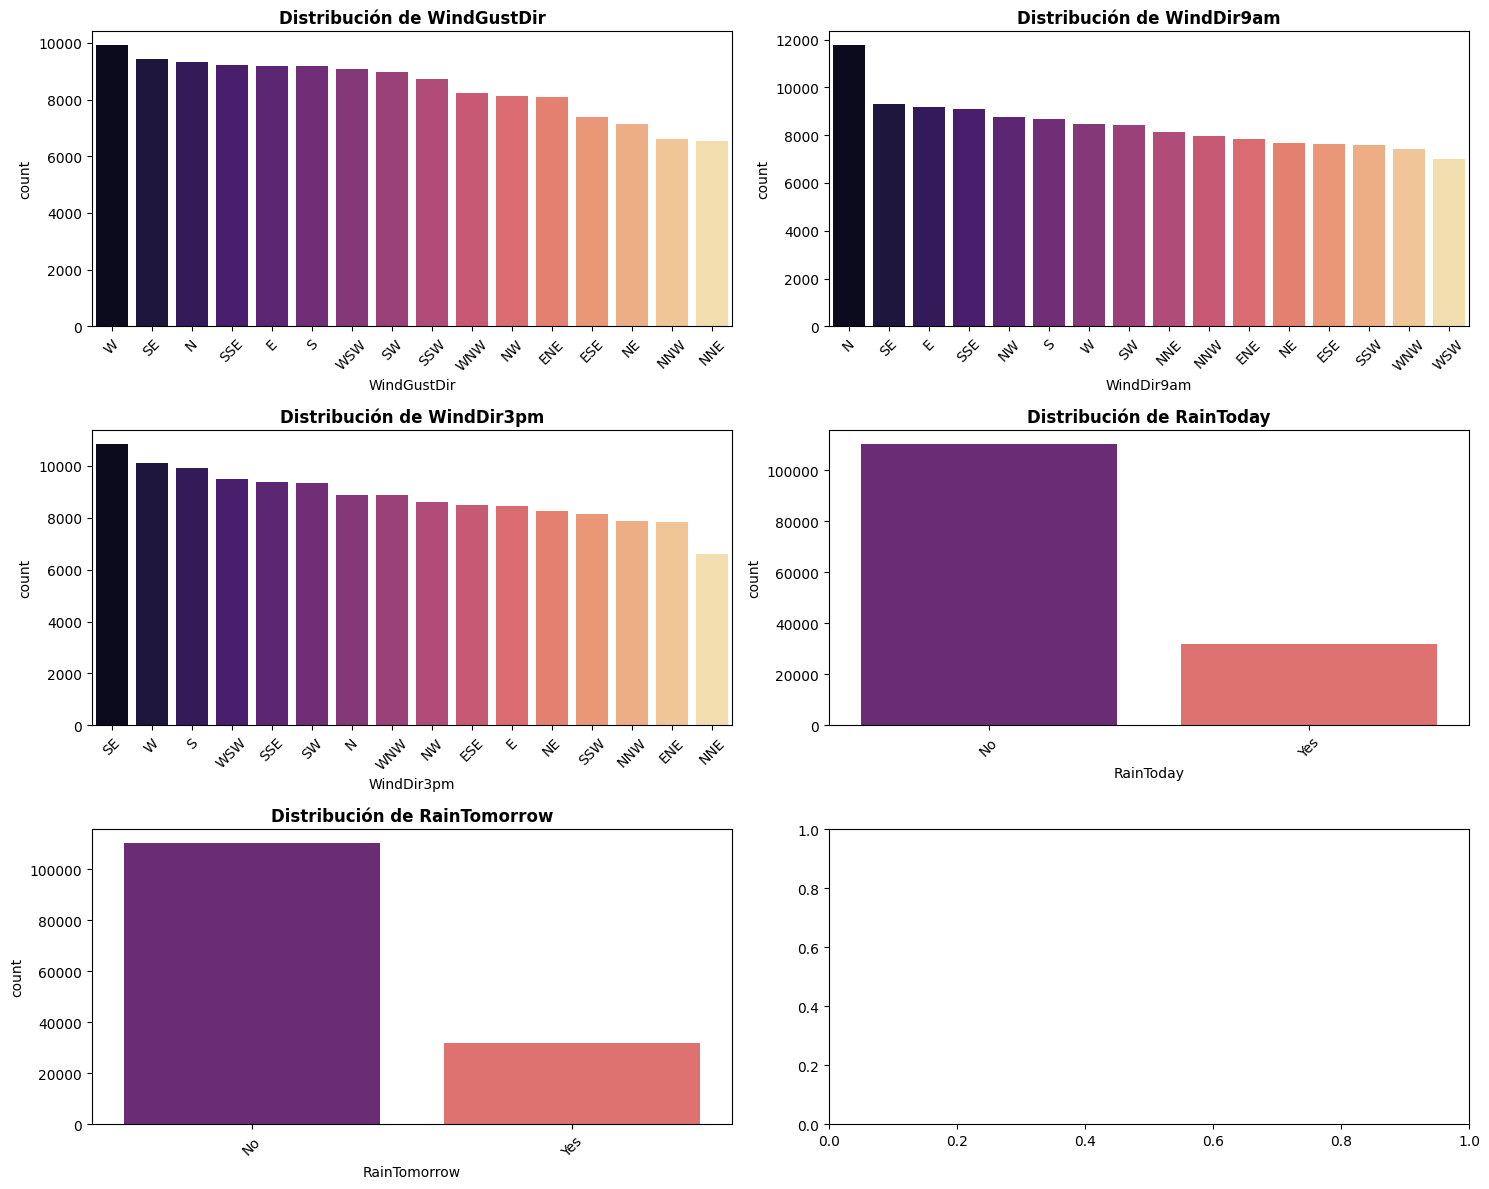

In [16]:
# Lista sin location
cols_sin_location = [col for col in cols_categoricas if col != 'Location']

# Crea el lienzo
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_sin_location):
    # Cuenta 
    sns.countplot(x=col, data=df, ax=axes[i], palette='magma',
                  order=df[col].value_counts().index)
    
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Interpretación de variables categóricas

Los gráficos muestran la distribución de las variables categóricas relacionadas con la dirección del viento y la presencia de lluvia.

Dirección del viento

Las variables "WindGustDir", "WindDir9am" y "WindDir3pm" presentan distribuciones relativamente equilibradas entre las distintas direcciones del viento.

Aunque aparecen con mayor frecuencia:
- En "WindGustDir" las direcciones "W" y "SE".
- En "WindDir9am" la dirección "N".
- En "WindDir3pm" las direcciones "SE" y "W".

Esto indica que ciertas direcciones del viento son más comunes en las ciudades analizadas.



RainToday

La variable "RainToday" muestra mayoría de la categoría "No".

Esto nos indica que en la mayoría de los días registrados, no hubo lluvia.



RainTomorrow

La variable objetivo "RainTomorrow" también presenta una mayoría de casos "No" respecto a "Yes".

Esto sugiere que el dataset se encuentra desbalanceado, ya que los días sin lluvia son considerablemente más frecuentes que los días con lluvia.

Este desbalance deberá tenerse en cuenta durante el entrenamiento y evaluación de los modelos de clasificación.

# Prueba de Normalidad

### Test D'Agostino-Pearson

In [17]:
from scipy import stats

ALPHA = 0.05
resultados = []

for col in cols_numericas:
    # Quitamos nulos solo para el test
    datos = df[col].dropna()
    
    # D'Agostino-Pearson
    stat, p_val = stats.normaltest(datos)
    
    resultados.append({
        'Variable': col,
        'Estadístico K2': f"{stat:.2f}",
        'p-valor': f"{p_val:.4f}",
        '¿Es Normal?': 'Si' if p_val > ALPHA else 'No'
    })

df_normalidad = pd.DataFrame(resultados)
print(df_normalidad)

         Variable Estadístico K2 p-valor ¿Es Normal?
0         MinTemp        2458.15  0.0000          No
1         MaxTemp        1494.61  0.0000          No
2        Rainfall      221533.93  0.0000          No
3     Evaporation       72314.38  0.0000          No
4        Sunshine       10184.00  0.0000          No
5   WindGustSpeed       16930.79  0.0000          No
6    WindSpeed9am       15322.02  0.0000          No
7    WindSpeed3pm        9441.56  0.0000          No
8     Humidity9am        5070.49  0.0000          No
9     Humidity3pm        2875.92  0.0000          No
10    Pressure9am         431.87  0.0000          No
11    Pressure3pm         124.72  0.0000          No
12       Cloud9am      491644.89  0.0000          No
13       Cloud3pm      594306.45  0.0000          No
14        Temp9am        1182.68  0.0000          No
15        Temp3pm        1413.24  0.0000          No


Optamos por el test de D'Agostino-Pearson porque combina el sesgo y la curtosis. Como el análisis descriptivo ya mostraba valores altos de curtosis en variables como Rainfall, este test valida formalmente de que no se puede asumir una distribución Gaussiana.

Al confirmar que ninguna variable es normal (p-valor < 0.05), justificamos técnicamente que en el preprocesamiento usaremos RobustScaler y para las correlaciones es preferible usar el coeficiente de Spearman sobre el de Pearson.

### QQPLOTS

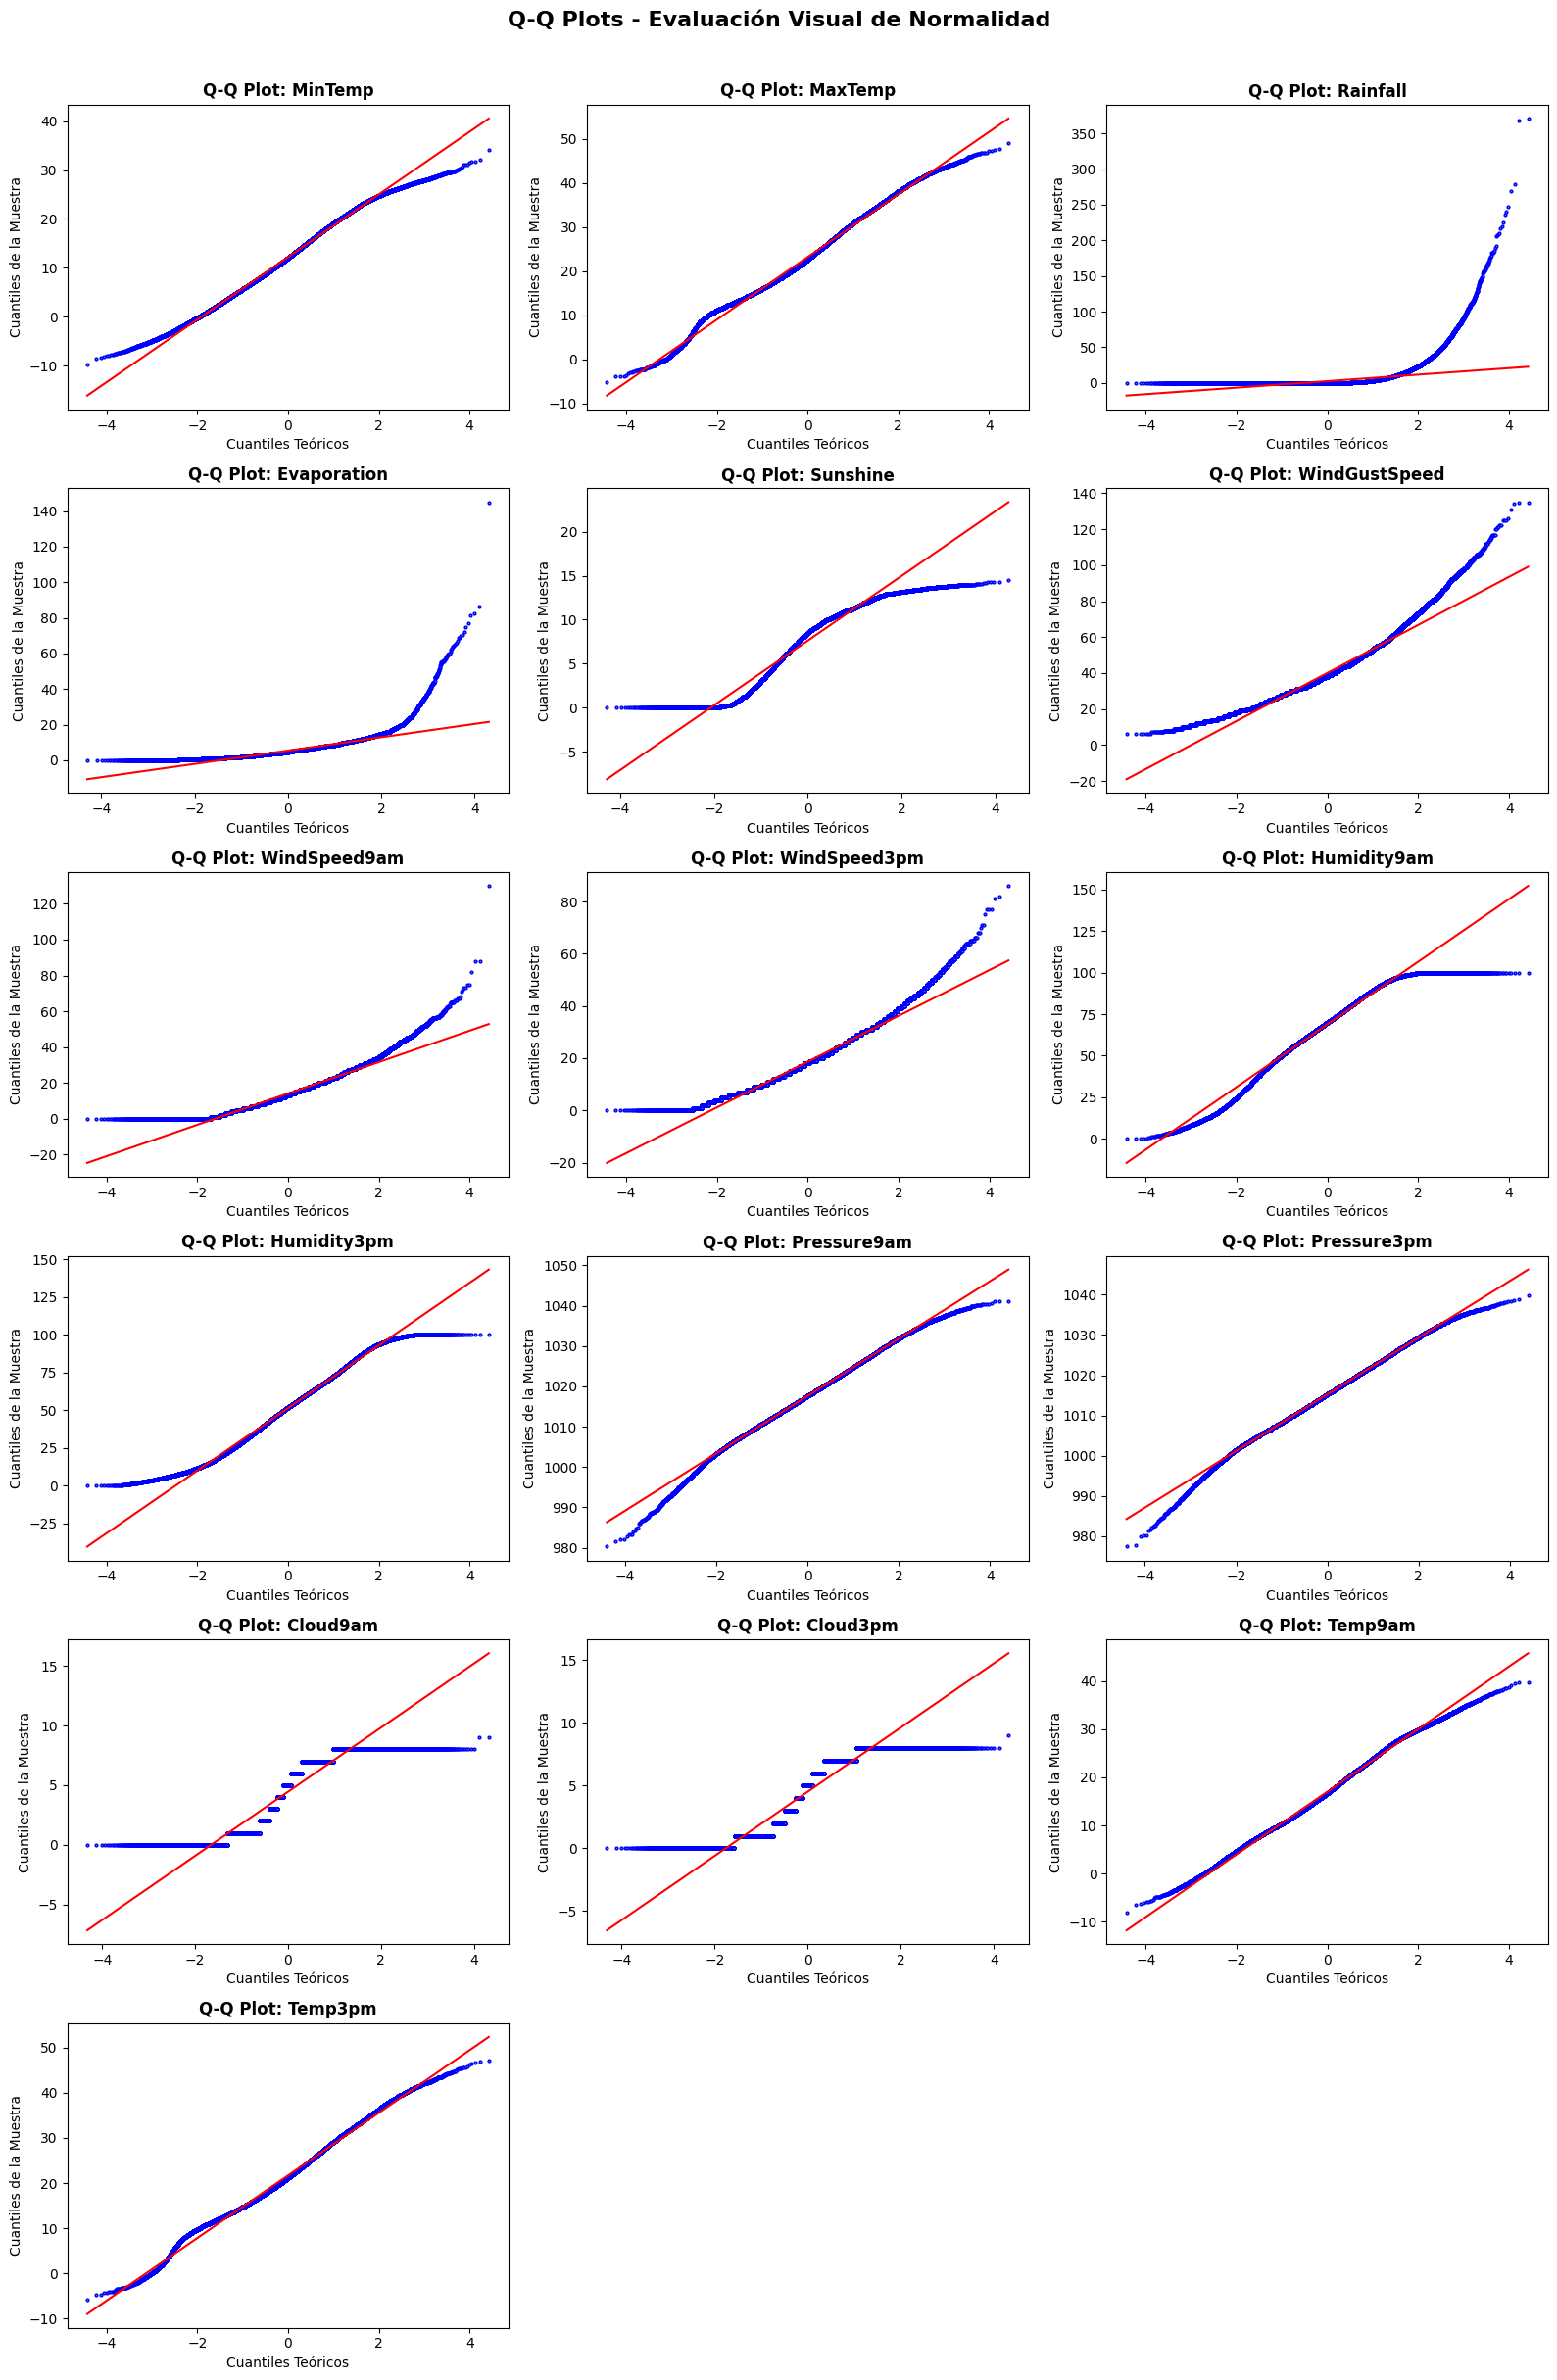

In [18]:
# Calculamos 3 columnas
n_cols = 3
n_rows = math.ceil(len(cols_numericas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    # quitamos nulos temporalmente
    datos = df[col].dropna()
    
    # Gráfico Q-Q
    stats.probplot(datos, dist='norm', plot=ax)
    
    
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue') # Puntos
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red') # Línea de referencia
    ax.set_xlabel('Cuantiles Teóricos')
    ax.set_ylabel('Cuantiles de la Muestra')

# Desactivamos cuadros sobrantes
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluación Visual de Normalidad', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") y presión ("Pressure9am", "Pressure3pm") muestran una distribución 

aproximadamente normal, los puntos siguen relativamente bien la línea de referencia.

Las variables como "Rainfall", "Evaporation" y las velocidades de viento presentan fuertes desviaciones respecto de la línea roja, indicando distribuciones

asimétricas y presencia de valores extremos.

Las variables "Cloud9am" y "Cloud3pm" muestran patrones escalonados debido a que son variables discretas.

Las variables de Humedad presentan una distribución parcialmente simétrica, aunque con desviaciones en los extremos.

En general, observamos que no todas las variables siguen una distribución normal, especialmente aquellas relacionadas con fenómenos climáticos extremos 

como lluvia y viento.

# Gestion de datos: Nulos, Duplicados, Consistencia

### Registros Nulos

In [19]:
# Verificamos si hay filas nulas
df.isna().all(axis=1).any()

np.False_

In [20]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
               Nulos  Porcentaje (%)            Tipo
Date               0        0.000000  datetime64[us]
Location           0        0.000000             str
MinTemp         1484        1.020549         float64
MaxTemp         1253        0.861690         float64
Rainfall        3260        2.241906         float64
Evaporation    62754       43.155998         float64
Sunshine       69796       47.998790         float64
WindGustDir    10316        7.094325             str
WindGustSpeed  10253        7.051000         float64
WindDir9am     10562        7.263500             str
WindDir3pm      4226        2.906225             str
WindSpeed9am    1767        1.215168         float64
WindSpeed3pm    3061        2.105053         float64
Humidity9am     2653        1.824471         float64
Humidity3pm     4505        3.098094         float64
Pressure9am    15061       10.357467         float64
Pressure3pm    15024       10.332022         float64
Cloud9am       55870

In [21]:
col_nulos = pct_nulos[pct_nulos>0].sort_values(ascending=False)

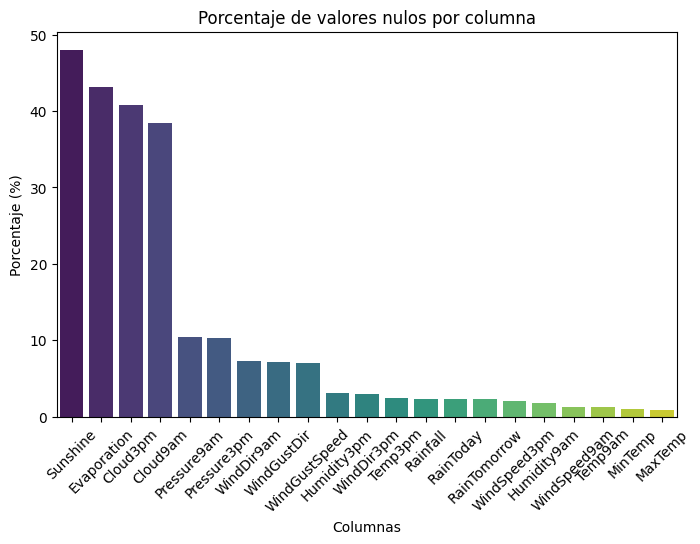

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Patrones de datos faltantes

Podemos observar que las variables con mas datos nulos son Sunshine, Evaporation, Cloud3pm y Cloud9am con mas del 35%.

No parecería un patrón completamente aleatorio (MCAR), ya que la cantidad de datos faltantes es muy alta. Se consideraría más 

razonable asumir los datos faltantes del tipo MAR (Missing At Random), donde la ausencia de datos puede depender de otras variables

observadas del dataset, como la ubicación ("Location") o la fecha ("Date").

Se evaluarán estrategias de imputación adecuadas segun el tipo de variable y el porcentaje de datos faltantes.



### Registros duplicados

In [23]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: conservar duplicados (pueden ser diamantes distintos con mismas specs)
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: En datos meteorológicos, cada registro representa una observación única \n'
          'en Ubicación/Fecha. La existencia de filas exactamente iguales \n'
          'indica una redundancia de datos o errores en la \n'
          'consolidación del dataset, y no eventos atmosféricos independientes.')
else:
    print('No se detectaron registros duplicados. La integridad temporal y espacial es correcta.')

Registros duplicados: 0 (0.00%)

No se detectaron registros duplicados. La integridad temporal y espacial es correcta.


### Registros inconsistentes

In [24]:
# Definimos las reglas lógicas
error_temp    = df['MinTemp'] > df['MaxTemp']
error_lluvia  = df['Rainfall'] < 0
error_humedad = (df['Humidity9am'] > 100) | (df['Humidity3pm'] > 100)
error_viento  = (df['WindGustSpeed'] < 0) | (df['WindSpeed9am'] < 0) | (df['WindSpeed3pm'] < 0)

# Aplicamos el reemplazo por NaN columna por columna
df.loc[error_temp, ['MinTemp', 'MaxTemp']] = np.nan
df.loc[error_lluvia, 'Rainfall'] = np.nan
df.loc[df['Humidity9am'] > 100, 'Humidity9am'] = np.nan
df.loc[df['Humidity3pm'] > 100, 'Humidity3pm'] = np.nan
df.loc[df['WindGustSpeed'] < 0, 'WindGustSpeed'] = np.nan
df.loc[df['WindSpeed9am'] < 0, 'WindSpeed9am'] = np.nan
df.loc[df['WindSpeed3pm'] < 0, 'WindSpeed3pm'] = np.nan

# Auditamos las columnas
cols_audit = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm', 
              'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

print(f'\nNuevos nulos:')
print(df[cols_audit].isnull().sum().to_dict())

print("\nDECISIÓN: No se eliminaron filas. Los datos erróneos o repetidos se marcaron como NaN "
      "para ser reparados en la etapa de imputación.")


Nuevos nulos:
{'MinTemp': 1554, 'MaxTemp': 1323, 'Rainfall': 3260, 'Humidity9am': 2653, 'Humidity3pm': 4505, 'WindGustSpeed': 10253, 'WindSpeed9am': 1767, 'WindSpeed3pm': 3061}

DECISIÓN: No se eliminaron filas. Los datos erróneos o repetidos se marcaron como NaN para ser reparados en la etapa de imputación.


# Análisis de Balanceo de Clases

In [25]:
# Analizamos el Target
target = 'RainTomorrow'
conteo = df[target].value_counts()
ir = conteo.max() / conteo.min()

print(f'DIAGNÓSTICO DEL TARGET: {target}')
print('=' * 40)
print(f'Clase mayoritaria (No llueve): {conteo.max()}')
print(f'Clase minoritaria (Sí llueve): {conteo.min()}')
print(f'Imbalance Ratio (IR): {ir:.2f}')

# Criterios de decisión
if ir > 5:
    status = "ALTO"
elif ir > 2.5:
    status = "MODERADO"
else:
    status = "ACEPTABLE"

print(f'Resultado: Desbalanceo {status}')
print('=' * 40)

DIAGNÓSTICO DEL TARGET: RainTomorrow
Clase mayoritaria (No llueve): 110281
Clase minoritaria (Sí llueve): 31872
Imbalance Ratio (IR): 3.46
Resultado: Desbalanceo MODERADO


Interpretación: Por cada día que llueve (Yes), hay aproximadamente 3.5 días en los que no llueve (No).

In [26]:
for col in cols_categoricas:
    conteo = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    clase_mayor = conteo.idxmax()
    clase_menor = conteo.idxmin()
    ir = conteo.max() / conteo.min()

    print(f'Variable: {col}')
    print('-' * 40)

    for cat in conteo.index:
        print(f'  {str(cat):>12s}: {conteo[cat]:>6d} ({pct[cat]:.2f}%)')

    print(f'  Clase mayoritaria: {clase_mayor} ({conteo.max()})')
    print(f'  Clase minoritaria: {clase_menor} ({conteo.min()})')
    print(f'  Imbalance Ratio (IR): {ir:.2f}')

    if ir > 5:
        print(f'  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.')
    elif ir > 2.5:
        print(f'  >> ATENCION: Desbalanceo moderado (IR > 2.5).')
    else:
        print(f'  >> Balanceo aceptable.')
    print()

Variable: Location
----------------------------------------
      Canberra:   3435 (2.36%)
        Sydney:   3343 (2.30%)
     Melbourne:   3192 (2.20%)
      Brisbane:   3192 (2.20%)
      Adelaide:   3192 (2.20%)
         Perth:   3192 (2.20%)
        Hobart:   3192 (2.20%)
        Darwin:   3192 (2.20%)
        Albury:   3039 (2.09%)
     Newcastle:   3039 (2.09%)
    Wollongong:   3039 (2.09%)
   MountGinini:   3039 (2.09%)
      Ballarat:   3039 (2.09%)
       Bendigo:   3039 (2.09%)
        Cairns:   3039 (2.09%)
     GoldCoast:   3039 (2.09%)
    Townsville:   3039 (2.09%)
  MountGambier:   3039 (2.09%)
        Albany:   3039 (2.09%)
    Launceston:   3039 (2.09%)
  AliceSprings:   3039 (2.09%)
       Penrith:   3038 (2.09%)
   Tuggeranong:   3038 (2.09%)
  BadgerysCreek:   3008 (2.07%)
         Cobar:   3008 (2.07%)
  CoffsHarbour:   3008 (2.07%)
         Moree:   3008 (2.07%)
  NorfolkIsland:   3008 (2.07%)
      Richmond:   3008 (2.07%)
  SydneyAirport:   3008 (2.07%)
    Wag

Las variables Location y Direcciones del Viento tienen un Balanceo Aceptable (IR entre 1.51 y 2.18).

Location (IR 2.18): La mayoría de las ciudades representan aprox. 2% del dataset. Tambien observamos que Nhil, Katherine y Uluru tienen la mitad de 

registros (aprox. 1%) que las ciudades principales. Esto sugiere que esas estaciones meteorológicas fueron instaladas más tarde o reportaron datos por 

menos tiempo.

Direcciones del Viento (IR ~1.6): Las direcciones están muy bien repartidas. No hay un viento que predomine de forma masiva sobre los demás, lo cual es

ideal para que el modelo aprenda la influencia de todas las direcciones por igual.

La Simetría entre RainToday y RainTomorrow es de IR (3.46) y porcentajes casi idénticos (77.58%). Esto indica una consistencia muy alta en el 

dataset. La probabilidad de que llueva "hoy" es la misma que la de "mañana" estadísticamente, lo que confirma que estamos ante un fenómeno climático 

estable en el tiempo.

# Análisis de Correlaciones y Colinealidad

Utilizaremos el Spearman por:

Falta de Normalidad: las pruebas de  D'Agostino-Pearson rechazaron la hipótesis nula de normalidad (p < 0.05) para todas las variables numéricas.

Presencia de Outliers Extremos: Variables como Rainfall mostraron una curtosis de +178.1, lo que indica "colas pesadas" o valores muy extremos (outliers).

Spearman es mucho más robusto ante outliers porque trabaja con rangos en lugar de valores exactos.

Relaciones No Lineales: En meteorología, muchas relaciones son monótonas (cuando una sube, la otra también) pero no necesariamente en línea recta. Spearman 

captura estas relaciones que Pearson ignoraría o subestimaría.

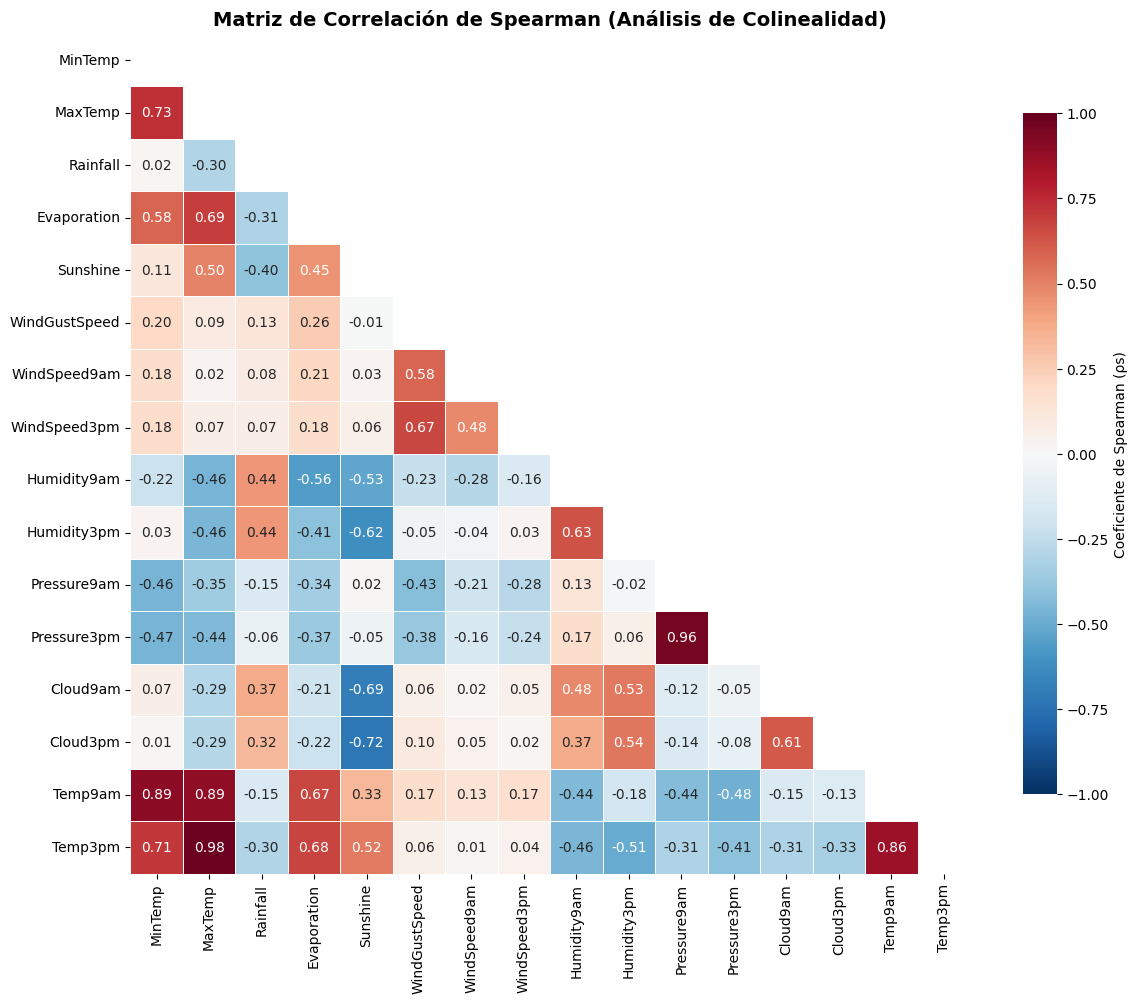

In [27]:
#  Calculamos la matriz usando Spearman 
corr_spearman = df[cols_numericas].corr(method='spearman')

#  Máscara triangular 
# np.triu crea una matriz de unos en la parte superior y la usamos para "tapar"
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman (ρs)'})

ax.set_title('Matriz de Correlación de Spearman (Análisis de Colinealidad)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se observan correlaciones positivas altas entre variables relacionadas con temperatura:

"MaxTemp" y "Temp3pm" (0.98)
"MinTemp" y "Temp9am" (0.89)
"Temp9am" y "MaxTemp" (0.89)

Esto indica que estas variables contienen información muy similar.

También se observan correlaciones negativas entre humedad y temperatura, lo que sugiere que a mayor temperatura suele disminuir la humedad relativa.

Por otro lado, las variables de presión ("Pressure9am" y "Pressure3pm") presentan una correlación extremadamente alta (0.96), indicando una fuerte relación 

entre ambas mediciones.

En general, las correlaciones observadas son coherentes con el comportamiento esperado de variables meteorológicas.

In [28]:
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |Spearman| >= {UMBRAL_COLINEALIDAD} (Colinealidad detectada):')
print('=' * 65)

pares_colineales = []

for i in range(len(corr_spearman.columns)):
    for j in range(i + 1, len(corr_spearman.columns)):
        r = corr_spearman.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_spearman.columns[i]
            var2 = corr_spearman.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: ρs = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).')
    print('Decisión: Estas variables son redundantes. Evaluaremos eliminar o usar PCA.')

Pares con |Spearman| >= 0.85 (Colinealidad detectada):
  MinTemp <-> Temp9am: ρs = 0.8935
  MaxTemp <-> Temp9am: ρs = 0.8866
  MaxTemp <-> Temp3pm: ρs = 0.9791
  Pressure9am <-> Pressure3pm: ρs = 0.9577
  Temp9am <-> Temp3pm: ρs = 0.8590

Se detectaron 5 par(es) colineal(es).
Decisión: Estas variables son redundantes. Evaluaremos eliminar o usar PCA.


### VIF

In [29]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

   Temp3pm: VIF =      37.96  << SEVERA
   MaxTemp: VIF =      32.90  << SEVERA
   Temp9am: VIF =      20.42  << SEVERA
  Pressure3pm: VIF =      18.47  << SEVERA
  Pressure9am: VIF =      18.45  << SEVERA
   MinTemp: VIF =       9.82  << MODERADA
  Humidity3pm: VIF =       5.90  << MODERADA
  Humidity9am: VIF =       3.98
  Sunshine: VIF =       3.32
  WindGustSpeed: VIF =       2.82
  Cloud3pm: VIF =       2.28
  Cloud9am: VIF =       2.24
  Evaporation: VIF =       2.21
  WindSpeed3pm: VIF =       2.11
  WindSpeed9am: VIF =       1.84
  Rainfall: VIF =       1.17


Colinealidad Severa (VIF > 10). Significa que estas variables están "explicadas" por las demás y son redundantes para el aprendizaje del modelo.


Temp3pm, MaxTemp, Temp9am: Presentan los valores más altos (VIF entre 20 y 38). Estas medidas estadísticamente están altamente correlacionadas entre sí.

Pressure3pm, Pressure9am: Ambos tienen un VIF de aproximadamente 18.5. Son variables "espejo" que aportan información redundante.

### Eliminación de variables

Se decide conservar únicamente MaxTemp. Esta variable presenta el menor índice de nulos (0.86%) en comparación con Temp3pm (2.48%) y Temp9am (1.21%). 

También, MaxTemp es un indicador robusto del calor máximo diario.

Se conserva Pressure3pm y se elimina Pressure9am porque ambas tienen VIFs casi idénticos (aprox. 18.5), pero Pressure3pm es cronológicamente más cercana al 

momento de la predicción (23:59hs), aportando información más fresca sobre el estado de la atmósfera antes del día siguiente.

In [30]:
# Eliminamos (Nulos > 40% y patrón MAR)
cols_baja_integridad = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
df = df.drop(columns=cols_baja_integridad)

# Eliminamos por Colinealidad Severa (VIF > 10)
cols_colineales = ['Temp3pm', 'Temp9am', 'Pressure9am']
df = df.drop(columns=cols_colineales)

# Actualizamos variables numéricas
cols_numericas = [c for c in cols_numericas if c not in (cols_baja_integridad + cols_colineales)]

print(f"Columnas eliminadas por integridad: {cols_baja_integridad}")
print(f"Columnas eliminadas por colinealidad: {cols_colineales}")

Columnas eliminadas por integridad: ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
Columnas eliminadas por colinealidad: ['Temp3pm', 'Temp9am', 'Pressure9am']


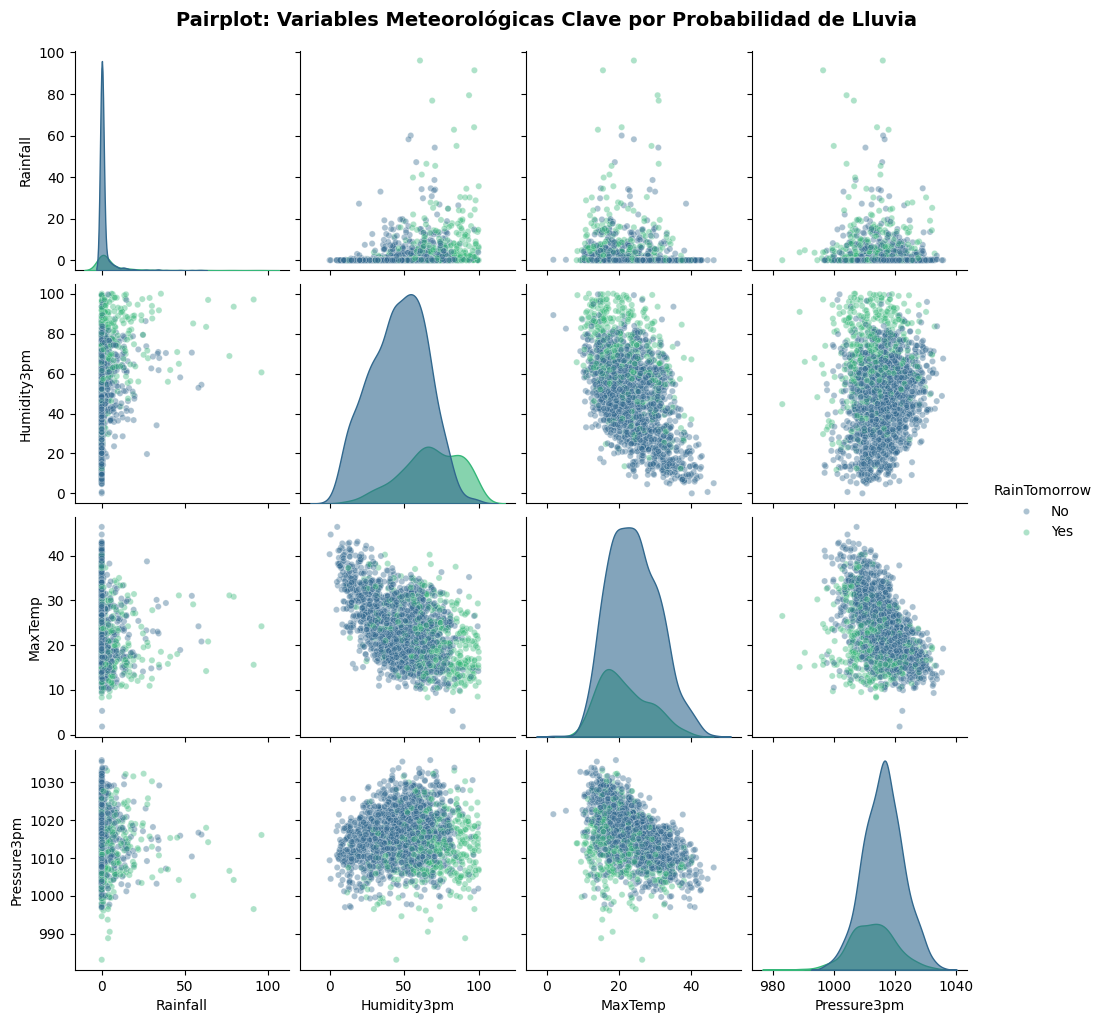

In [31]:
#  Variables basadas en el análisis de VIF
vars_analisis = ['Rainfall', 'Humidity3pm', 'MaxTemp', 'Pressure3pm']
target = 'RainTomorrow'

#  Pairplot
# Usamos una muestra 
g = sns.pairplot(df[vars_analisis + [target]].dropna().sample(2000, random_state=42),
                 hue=target, 
                 palette='viridis',
                 plot_kws={'alpha': 0.4, 's': 20}, 
                 diag_kws={'alpha': 0.6})

# Visualización
g.figure.suptitle('Pairplot: Variables Meteorológicas Clave por Probabilidad de Lluvia',
                  fontsize=14, fontweight='bold', y=1.02)

plt.show()

Se observa que los casos donde sí llueve ("Yes") suelen estar asociados con:
- mayores valores de "Rainfall"
- mayor humedad ("Humidity3pm")
- menores valores de presión ("Pressure3pm")
- temperaturas máximas más bajas ("MaxTemp")

También, se identifican relaciones inversas entre algunas variables, por ejemplo:
- a mayor temperatura máxima, menor humedad
- a mayor presión, menor probabilidad de lluvia

En general, las variables seleccionadas muestran patrones diferenciados entre días con lluvia y sin lluvia, lo que indica que podrían ser útiles para los modelos de clasificación.

# Detección de Outliers

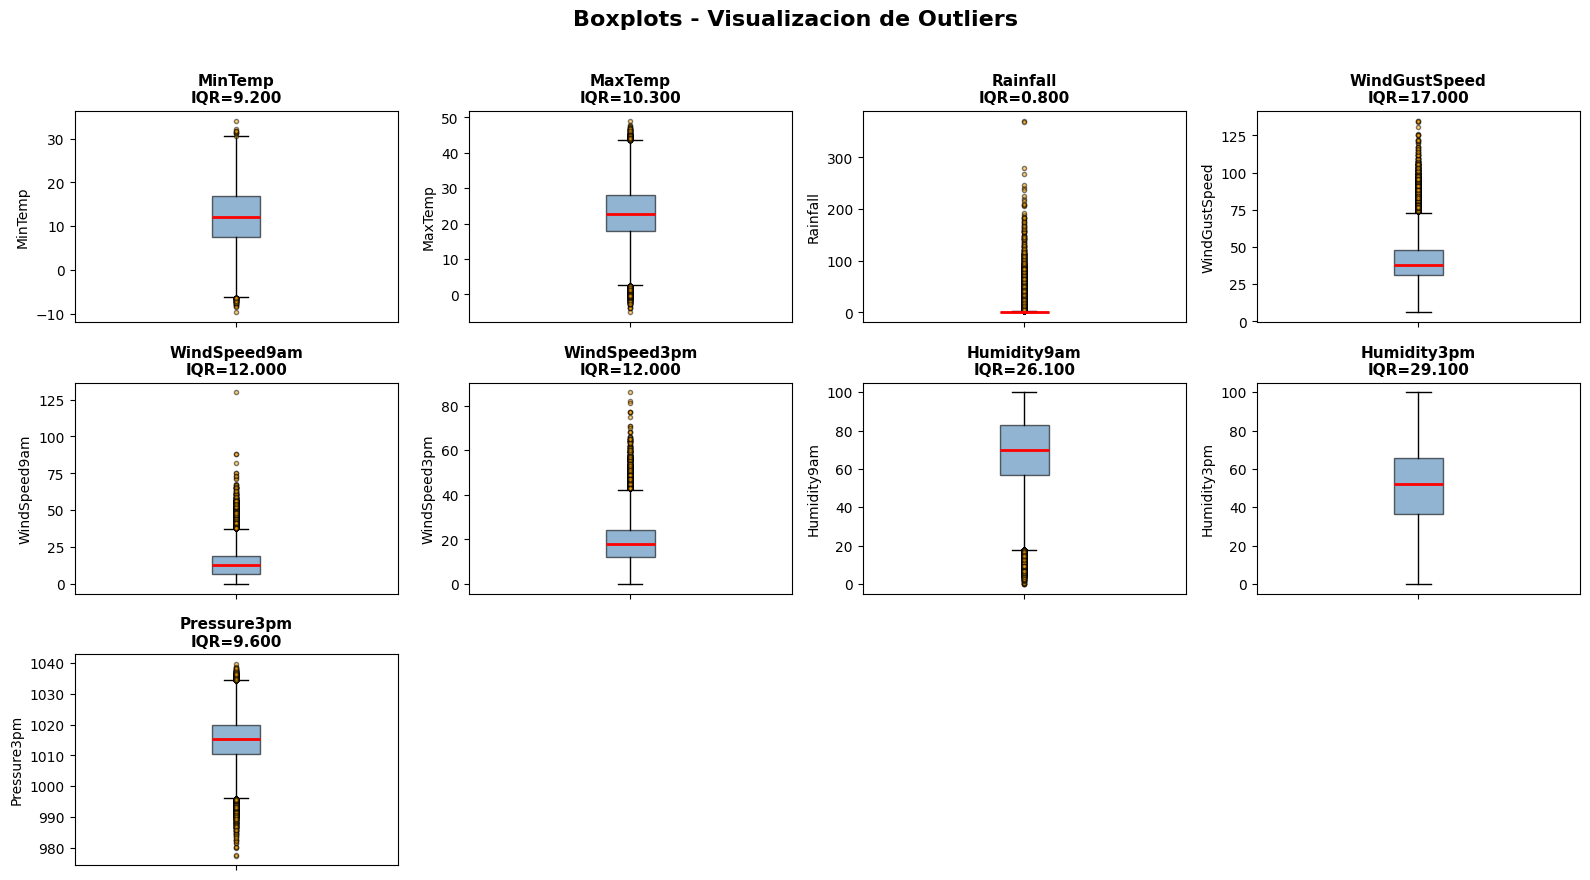

In [32]:
fig, axes = plt.subplots(5, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se observa que variables "Rainfall", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm" presentan una gran cantidad de outliers y 

distribuciones asimétricas, especialmente hacia valores altos.

Se observa que variables como "MinTemp", "MaxTemp", "Pressure3pm" muestran distribuciones más estables y con menor cantidad de valores extremos.

En general, los outliers observados son coherentes con fenómenos meteorológicos extremos y no necesariamente representan errores en los datos.

# División Train-Test

In [33]:
df = df.dropna(subset=['RainTomorrow'])

# Definimos X e y
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    stratify=y, random_state=42)

# Feature Engineering

Creamos la variable 'Season' adaptada al hemisferio sur para capturar la estacionalidad australiana, y variables de interacción como el 'TempRange' y 

'HumDiff'. Estas son fundamentales porque el gradiente de humedad y la amplitud térmica diaria son indicadores físicos de inestabilidad atmosférica mucho

más potentes que las mediciones aisladas de la mañana o la tarde.

In [ ]:
# funcion 
def aplicar_ingenieria_variables(df):
    
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    
    # Mapeo según el hemisferio sur
    season_map = {
        12: 'Summer', 1: 'Summer', 2: 'Summer',
        3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
        6: 'Winter', 7: 'Winter', 8: 'Winter',
        9: 'Spring', 10: 'Spring', 11: 'Spring'
    }
    df['Season'] = df['Month'].map(season_map)
    
    # Variables de Amplitud térmica
    
    df['TempRange'] = df['MaxTemp'] - df['MinTemp']
    
    # Interacción de Humedad 
    
    df['HumDiff'] = df['Humidity3pm'] - df['Humidity9am']
    
    # Diferencia de Presión

    if 'Pressure9am' in df.columns and 'Pressure3pm' in df.columns:
        df['PressureDiff'] = df['Pressure3pm'] - df['Pressure9am']
    
    return df


X_train = aplicar_ingenieria_variables(X_train.copy())
X_test = aplicar_ingenieria_variables(X_test.copy())

# ACTUALIZACIÓN DE LISTAS 

# Se agrega season
if 'Season' not in cols_categoricas:
    cols_categoricas.append('Season')

# Agregamos las nuevas numéricas
nuevas_num = ['TempRange', 'HumDiff', 'PressureDiff']
for col in nuevas_num:
    if col in X_train.columns and col not in cols_numericas:
        cols_numericas.append(col)

print("Feature Engineering exitoso.")
print(f"Columnas actuales: {X_train.shape[1]}")

Feature Engineering exitoso.
Columnas actuales: 19


In [57]:
# Variables para eliminar

cols_redundantes = ['Date', 'Month'] 

X_train = X_train.drop(columns=cols_redundantes)
X_test = X_test.drop(columns=cols_redundantes)

# Imputacion de datos

Descartamos el Z-Score debido a que nuestras pruebas de D'Agostino-Pearson confirmaron distribuciones no normales y variables con curtosis leptocúrtica extrema. Optamos por el Método IQR, ya que es un estadístico robusto que no se deja arrastrar por el sesgo

In [58]:

cols_numericas = [c for c in cols_numericas if c in X_train.columns]
cols_categoricas = [c for c in cols_categoricas if c in X_train.columns]


# IMPUTACIÓN DE VARIABLES NUMÉRICAS (Mediana)

for col in cols_numericas:
    # Calculamos el estadístico solo en Train para evitar Data Leakage
    mediana_train = X_train[col].median()
    
    # Aplicamos a ambos conjuntos
    X_train[col] = X_train[col].fillna(mediana_train)
    X_test[col] = X_test[col].fillna(mediana_train)

# IMPUTACIÓN DE VARIABLES CATEGÓRICAS (Moda)

for col in cols_categoricas:
    
    moda_train = X_train[col].mode()[0]
    
    # Aplicamos a ambos conjuntos
    X_train[col] = X_train[col].fillna(moda_train)
    X_test[col] = X_test[col].fillna(moda_train)

# AUDITORÍA 

nulos_finales = X_train.isnull().sum().sum()
print(f"Imputación completada. Total de nulos remanentes en X_train: {nulos_finales}")
if nulos_finales == 0:
    print("Estado del dataset: INTEGRIDAD TOTAL (Listo para codificación y escalado)")

Imputación completada. Total de nulos remanentes en X_train: 0
Estado del dataset: INTEGRIDAD TOTAL (Listo para codificación y escalado)


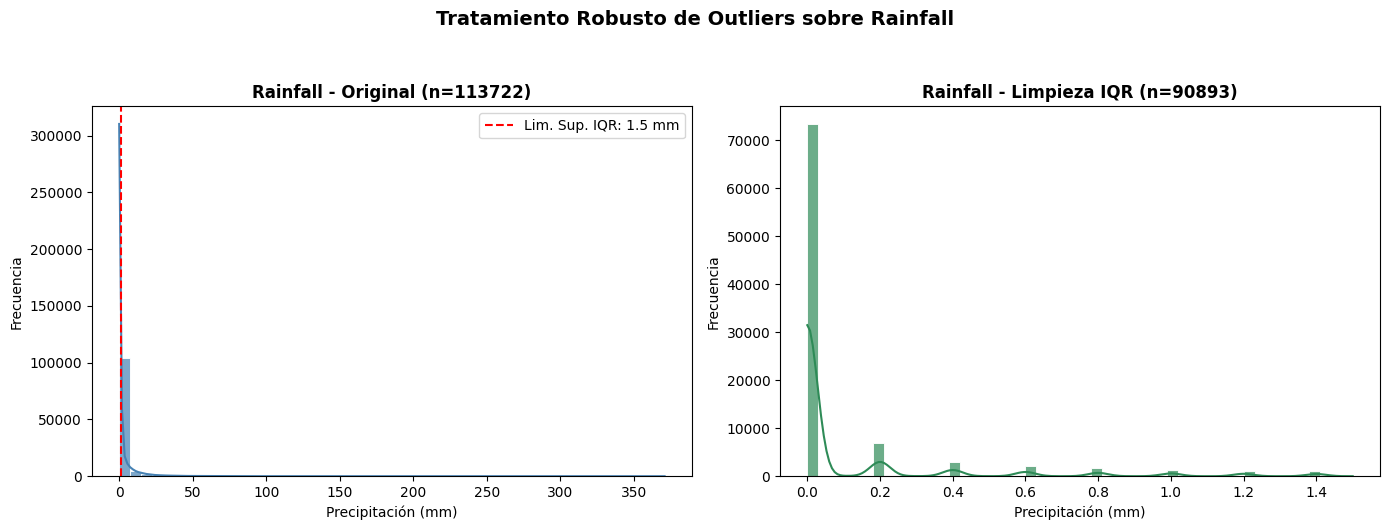

Análisis de Rainfall:
  - Registros considerados outliers: 22829
  - Porcentaje de limpieza: 20.07%


In [60]:
# Elegimos una columna con muchos outliers
col_ejemplo = 'Rainfall'
IQR_FACTOR = 1.5

# Tomamos datos sin nulos
datos = X_train[col_ejemplo]

# Cálculo de Límites Robustos (IQR)
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

# Filtrado para la visualización
datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Con Outliers
sns.histplot(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7, ax=axes[0], kde=True)
axes[0].axvline(lim_sup, color='red', linestyle='--', 
                label=f'Lim. Sup. IQR: {lim_sup:.1f} mm')
axes[0].set_title(f'{col_ejemplo} - Original (n={len(datos)})', fontweight='bold')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Gráfico 2: Sin Outliers (Efecto de la Limpieza)
sns.histplot(datos_sin_outliers, bins=50, color='seagreen', edgecolor='white', alpha=0.7, ax=axes[1], kde=True)
axes[1].set_title(f'{col_ejemplo} - Limpieza IQR (n={len(datos_sin_outliers)})', fontweight='bold')
axes[1].set_xlabel('Precipitación (mm)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Tratamiento Robusto de Outliers sobre {col_ejemplo}', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Resumen 
eliminados = len(datos) - len(datos_sin_outliers)
print(f'Análisis de {col_ejemplo}:')
print(f'  - Registros considerados outliers: {eliminados}')
print(f'  - Porcentaje de limpieza: {(eliminados / len(datos)) * 100:.2f}%')

Tomamos la decisión de no eliminar estos registros porque al hacerlo eliminaría la variabilidad más importante de nuestro target (los días de lluvia). En 

su lugar, optamos por un RobustScaler, que utiliza la mediana y el rango intercuartílico para normalizar los datos, permitiendo que el modelo aprenda de 

estos valores extremos sin que su magnitud distorsione los pesos del algoritmo de clasificación".

# Escalado

In [61]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[cols_numericas]),
    columns=cols_numericas,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[cols_numericas]),
    columns=cols_numericas,
    index=X_test.index
)

# Verificación técnica del escalado robusto
print('Verificación post-escalado Robusto (X_train):')
print('=' * 65)
verificacion = pd.DataFrame({
    'Mediana': X_train_scaled.median(),
    'IQR': X_train_scaled.quantile(0.75) - X_train_scaled.quantile(0.25),
    'Min': X_train_scaled.min(),
    'Max': X_train_scaled.max()
})
print(verificacion.round(3))

print('\nInterpretación: Mediana ≈ 0 e IQR ≈ 1. Los valores Max altos son outliers preservados.')

Verificación post-escalado Robusto (X_train):
               Mediana  IQR    Min      Max
MinTemp            0.0  1.0 -2.359    2.402
MaxTemp            0.0  1.0 -2.689    2.573
Rainfall           0.0  1.0  0.000  618.333
WindGustSpeed      0.0  1.0 -2.000    6.062
WindSpeed9am       0.0  1.0 -1.083    6.250
WindSpeed3pm       0.0  1.0 -1.500    5.333
Humidity9am        0.0  1.0 -2.713    1.163
Humidity3pm        0.0  1.0 -1.837    1.696
Pressure3pm        0.0  1.0 -4.554    2.964
TempRange          0.0  1.0 -3.397    2.904
HumDiff            0.0  1.0 -3.457    4.878

Interpretación: Mediana ≈ 0 e IQR ≈ 1. Los valores Max altos son outliers preservados.


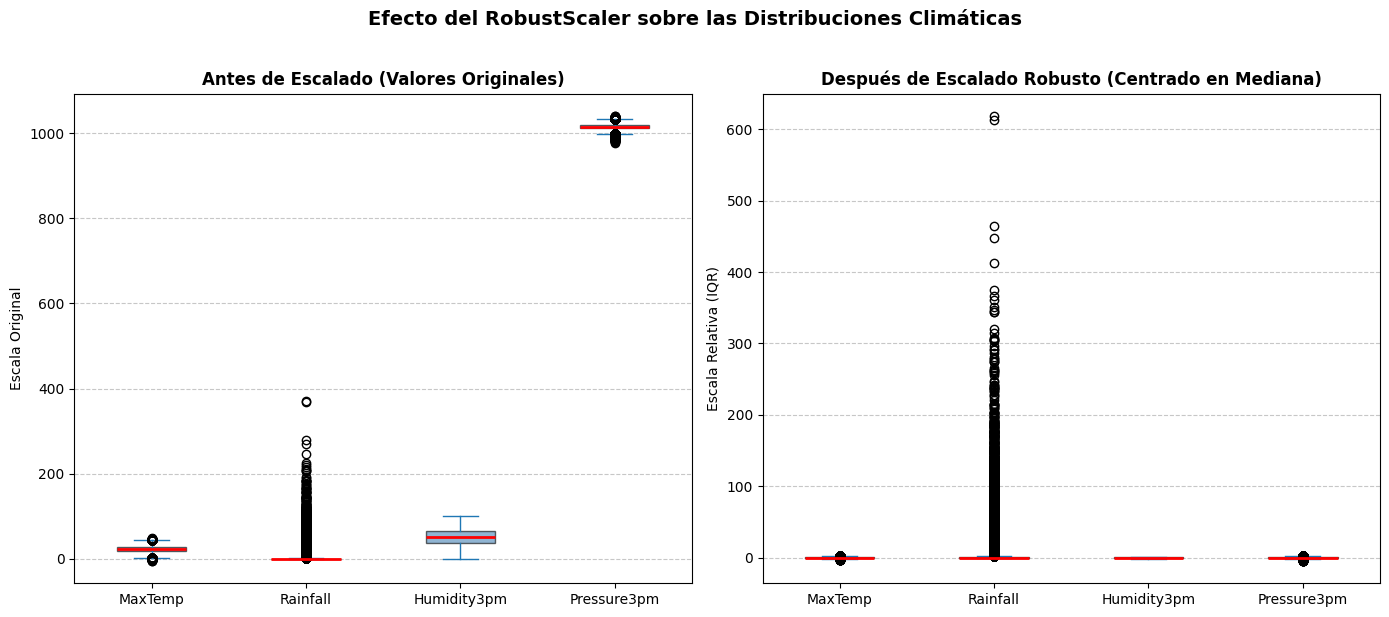

In [62]:
# Seleccionamos variables con diferentes escalas para ver el efecto

vars_box = ['MaxTemp', 'Rainfall', 'Humidity3pm', 'Pressure3pm']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GRÁFICO 1: ANTES (Valores Originales) 

X_train[vars_box].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Antes de Escalado (Valores Originales)', fontweight='bold')
axes[0].set_ylabel('Escala Original')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# GRÁFICO 2: DESPUÉS (Robust Scaling) 

X_train_scaled[vars_box].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Después de Escalado Robusto (Centrado en Mediana)', fontweight='bold')
axes[1].set_ylabel('Escala Relativa (IQR)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Efecto del RobustScaler sobre las Distribuciones Climáticas', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Codificación

In [ ]:
# Variables categóricas finales
categorias_ohe = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Location']

# Se aplica One-Hot Encoding

X_train_final = pd.get_dummies(X_train, columns=categorias_ohe, drop_first=True)
X_test_final = pd.get_dummies(X_test, columns=categorias_ohe, drop_first=True)

# Alineación de columnas (Asegura que Test tenga las mismas columnas que Train)

X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

# Eliminamos 'Date' 
if 'Date' in X_train_final.columns:
    X_train_final = X_train_final.drop(columns=['Date'])
    X_test_final = X_test_final.drop(columns=['Date'])

print(f"Dimensiones finales del set de entrenamiento: {X_train_final.shape}")
print(f"Número de variables tras OHE: {len(X_train_final.columns)}")

Dimensiones finales del set de entrenamiento: (113722, 106)
Número de variables tras OHE: 106


A pesar de tener más de 100 variables, el modelo es robusto porque contamos con una cantidad de registros muy superior (más de 1,000 ejemplos por cada

 variable), lo que mitiga el riesgo de overfitting

In [64]:
# Comprobamos
print(f"Hay nulos: {X_train_final.isnull().any().any()}")
print(f"Todos los datos son numéricos: {all(X_train_final.dtypes != 'object')}")

Hay nulos: False
Todos los datos son numéricos: True
